## Задание

Распознайте рукописную цифру, написанную на листе от руки.
Последовательность шагов следующая:

*   На бумаге рисуем произвольную цифру (желательно нарисовать цифру размером не
более 5 * 5 мм и без наклона. В занятии нейронка обучалась на цифрах американских студентов. Эти цифры были написаны на тетрадных листах в клетку и имели схожий размер).
*   Фотографируем. Загружаем фото в Collaboratory.
*   С помощью функции image.load_img(path, target_size=(28, 28), color_mode = ‘grayscale’) загружаем картинку в переменную.
*   С помощью функции image.img_to_array(img) преобразуем изображение в numpy-массив.
*   Выполняем инверсию цветов, нормирование и решейп массива.
*   Выполняем распознавание собственной рукописной цифры.

Примечание: точность распознавания рукописных цифр может быть достаточно низкой, т.к. рукописные цифры после преобразований хоть и похожи на содержащиеся в базе, но могут отличаться по конфигурации, толщине линий и т.д.

In [14]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# 1) загрузка MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2) подготовка: нормализация + flatten
x_train = (x_train.astype("float32") / 255.0).reshape(-1, 784)
x_test  = (x_test.astype("float32") / 255.0).reshape(-1, 784)

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

# 3) модель
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax"),
])

model.compile(optimizer=Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# 4) обучение
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1, verbose=1)

# 5) проверка
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", round(float(acc), 4))

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8971 - loss: 0.3593 - val_accuracy: 0.9583 - val_loss: 0.1487
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9564 - loss: 0.1481 - val_accuracy: 0.9705 - val_loss: 0.1063
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9694 - loss: 0.1034 - val_accuracy: 0.9732 - val_loss: 0.0916
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9768 - loss: 0.0760 - val_accuracy: 0.9747 - val_loss: 0.0874
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0608 - val_accuracy: 0.9762 - val_loss: 0.0833
Test accuracy: 0.9737


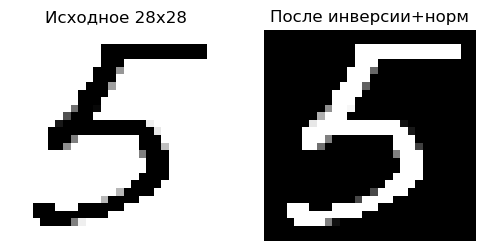

x shape: (1, 784)


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def preprocess_my_digit(path):
    # 1) load_img: 28x28 grayscale
    img = image.load_img(path, target_size=(28, 28), color_mode="grayscale")
    arr = image.img_to_array(img)            # (28, 28, 1)

    # 2) перевод в [0..1]
    arr = arr.astype("float32") / 255.0

    # 3) инверсия (MNIST: фон чёрный, цифра светлая; на фото часто наоборот)
    arr = 1.0 - arr

    # 4) reshape под модель: (1, 784)
    x = arr.reshape(1, 28*28)

    return img, arr, x

# пример: путь к загруженному файлу
path = "my_digit5.jpg"
img, arr, x = preprocess_my_digit(path)

# покажем исходное и обработанное
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Исходное 28x28")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(arr.squeeze(), cmap="gray")
plt.title("После инверсии+норм")
plt.axis("off")
plt.show()

print("x shape:", x.shape)

In [86]:
pred = model.predict(x, verbose=0)          # (1,10)
digit = int(np.argmax(pred, axis=1)[0])
conf = float(np.max(pred))

print("Распознанная цифра:", digit)
print("Уверенность:", round(conf, 4))
print("Вероятности по классам:", np.round(pred[0], 4))

Распознанная цифра: 5
Уверенность: 0.9997
Вероятности по классам: [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 9.997e-01 3.000e-04
 0.000e+00 0.000e+00 0.000e+00]


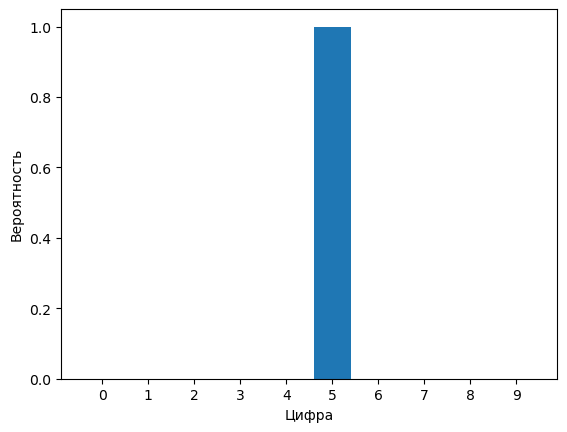

In [88]:
import matplotlib.pyplot as plt
import numpy as np

probs = model.predict(x, verbose=0)[0]
plt.figure()
plt.bar(np.arange(10), probs)
plt.xticks(np.arange(10))
plt.xlabel("Цифра")
plt.ylabel("Вероятность")
plt.show()